# Conjunto de dados de eventos de mercado de notícias financeiras para PNL 2025
Dados de eventos de mercado em tempo real: sentimento, volume de negociação e níveis de impacto em 2025

# Visão geral
Este conjunto de dados sintéticos contém 3.024 registros de manchetes de notícias financeiras centradas nos principais eventos de mercado de fevereiro de 2025 a agosto de 2025. O conjunto de dados captura a dinâmica do mercado em tempo real, análise de sentimento e padrões de negociação em mercados financeiros globais, tornando-o ideal para análises financeiras, modelagem de sentimento e tarefas de previsão de mercado.

# Especificações do conjunto de dados
Total de registros : 3.024 linhas
Total de recursos : 12 colunas
Período : 1º de fevereiro de 2025 - 14 de agosto de 2025
Formatos de arquivo : CSV, JSON, XLSX
Qualidade dos dados : ~5% de valores nulos distribuídos estrategicamente para cenários realistas de limpeza de dados

# Cobertura de Eventos de Mercado (20 Categorias)
Quedas e altas do mercado de ações
Mudanças nas taxas de juros e reuniões do Banco Central
Relatórios de Lucros Corporativos e Lançamentos de IPOs
Anúncios de Políticas Governamentais
Tarifas Comerciais e Eventos Geopolíticos
Regulamentos de Criptomoedas
Interrupções na cadeia de suprimentos
Divulgações de Dados Econômicos
Índices de Mercado Global (18 Índices Principais)
Mercados dos EUA : S&P 500, Dow Jones, Nasdaq Composite, Russell 2000
Mercados indianos : NSE Nifty, BSE Sensex
Mercados europeus : FTSE 100, DAX, Euro Stoxx 50, CAC 40
Mercados asiáticos : Nikkei 225, Hang Seng, Shanghai Composite, KOSPI
Outros : TSX, ASX 200, IBOVESPA, S&P/TSX Composite
Fontes de notícias (18 publicações respeitáveis)
Principais veículos de notícias financeiras, incluindo Reuters, Bloomberg, CNBC, Financial Times, Wall Street Journal, Economic Times, Forbes e publicações financeiras especializadas.

# Distribuição Setorial (18 Setores de Negócios)
Tecnologia, finanças, saúde, energia, bens de consumo, serviços públicos, indústria, materiais, imóveis, telecomunicações, automotivo, varejo, produtos farmacêuticos, aeroespacial e defesa, agricultura, transporte, mídia e entretenimento, construção.

# Notas sobre qualidade de dados e pré-processamento
Distribuição nula realista : aproximadamente 5% de valores nulos em colunas-chave (título, sentimento, porcentagem de alteração do índice, URL da notícia) para simular desafios de coleta de dados do mundo real
Distribuição de sentimentos equilibrada : mistura de classificações de sentimentos positivos, neutros e negativos
Condições de mercado diversas : mudanças no índice variando de -5% a +5% refletindo vários cenários de mercado
Variabilidade de volume : os volumes de negociação variam de 1 milhão a 500 milhões para representar diferentes condições de liquidez do mercado
Possíveis casos de uso
# 📈 Análise Financeira
Análise de sentimento de mercado e previsão de tendências
Estudos de correlação entre eventos de notícias e movimentos de mercado
Análise de padrões de volume de negociação
# 🤖 Aplicações de Aprendizado de Máquina
Treinamento do modelo de classificação de sentimentos
Algoritmos de previsão de movimento de mercado
Modelos de geração de manchetes de notícias
Desenvolvimento de estratégia de negociação orientada a eventos
# 📊 Projetos de Visualização de Dados
Painéis interativos de sentimento de mercado
Análise de séries temporais de eventos de mercado
Distribuição geográfica do impacto das notícias financeiras
Visualização de desempenho por setor
# 🔍 Aplicações de Pesquisa
Pesquisa acadêmica sobre eficiência de mercado
Análise de impacto de notícias em diferentes setores
Estudos de correlação entre mercados
Metodologias de estudo de eventos
Especificações técnicas
Uso de memória : aproximadamente 1,5 MB em todos os formatos
Recomendações de processamento : adequado para operações de DataFrame do Pandas, análise de SQL e a maioria das estruturas de ML
Escalabilidade : otimizado para análises em pequena escala e tarefas de modelagem em larga escala

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [2]:
sns.set_style("whitegrid")

In [3]:
try:
    df = pd.read_csv('financial_news_events.xlsx - Sheet1.csv')
    print("DataFrame carregado com sucesso a partir de 'financial_news_events.xlsx - Sheet1.csv'.")
except FileNotFoundError:
    try:
        df = pd.read_csv('financial_news_events.csv')
        print("DataFrame carregado com sucesso a partir de 'financial_news_events.csv'.")
    except FileNotFoundError:
        print("Erro: Nenhum dos arquivos de dados foi encontrado. Por favor, verifique o nome do arquivo.")
        df = None

if df is not None:
    
    print("Informações do DataFrame Original")
    df.info()

DataFrame carregado com sucesso a partir de 'financial_news_events.csv'.
Informações do DataFrame Original
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  3024 non-null   object 
 1   Headline              2876 non-null   object 
 2   Source                3024 non-null   object 
 3   Market_Event          3024 non-null   object 
 4   Market_Index          3024 non-null   object 
 5   Index_Change_Percent  2863 non-null   float64
 6   Trading_Volume        3024 non-null   float64
 7   Sentiment             2853 non-null   object 
 8   Sector                3024 non-null   object 
 9   Impact_Level          3024 non-null   object 
 10  Related_Company       3024 non-null   object 
 11  News_Url              2871 non-null   object 
dtypes: float64(2), object(10)
memory usage: 283.6+ KB


In [4]:
#Converter a coluna 'Date' para o formato de data e hora
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
#Valores nulos na coluna 'Sentiment' com 'Unknown' para análise
df['Sentiment'] = df['Sentiment'].fillna('Unknown')

In [6]:
print('Informações Após Limpeza')
df.info()
print('Análise:')
print(df.head())

Informações Após Limpeza
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  3024 non-null   datetime64[ns]
 1   Headline              2876 non-null   object        
 2   Source                3024 non-null   object        
 3   Market_Event          3024 non-null   object        
 4   Market_Index          3024 non-null   object        
 5   Index_Change_Percent  2863 non-null   float64       
 6   Trading_Volume        3024 non-null   float64       
 7   Sentiment             3024 non-null   object        
 8   Sector                3024 non-null   object        
 9   Impact_Level          3024 non-null   object        
 10  Related_Company       3024 non-null   object        
 11  News_Url              2871 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(9)
memory 

In [7]:
#Análise de Sentimento e sua relação com a mudança de mercado
print("Análise de Sentimento")
sentiment_counts = df['Sentiment'].value_counts()
print("Distribuição de Sentimentos:")
print(sentiment_counts)

avg_change_by_sentiment = df.groupby('Sentiment')['Index_Change_Percent'].mean()
print("Média de Mudança do Índice (%) por Sentimento:")
print(avg_change_by_sentiment)

Análise de Sentimento
Distribuição de Sentimentos:
Sentiment
Negative    974
Neutral     951
Positive    928
Unknown     171
Name: count, dtype: int64
Média de Mudança do Índice (%) por Sentimento:
Sentiment
Negative   -0.035822
Neutral     0.096839
Positive   -0.106007
Unknown    -0.134025
Name: Index_Change_Percent, dtype: float64


In [8]:
#Correlação entre volume de negociação e mudança do índice
print("Análise de Correlação")
correlation = df[['Index_Change_Percent', 'Trading_Volume']].corr()
print("Matriz de Correlação:")
print(correlation)

Análise de Correlação
Matriz de Correlação:
                      Index_Change_Percent  Trading_Volume
Index_Change_Percent              1.000000       -0.009637
Trading_Volume                   -0.009637        1.000000


In [9]:
df['Market_Direction'] = df['Index_Change_Percent'].apply(lambda x: 'Positivo' if x > 0 else 'Negativo' if x < 0 else 'Neutro')

In [10]:
#Contagem cruzada para ver a correspondência entre Sentimento e Direção do Mercado
print("Correspondência entre Sentimento da Notícia e Direção do Mercado")
cross_tab = pd.crosstab(df['Sentiment'], df['Market_Direction'], normalize='index') * 100
print(cross_tab)

Correspondência entre Sentimento da Notícia e Direção do Mercado
Market_Direction   Negativo    Neutro   Positivo
Sentiment                                       
Negative          48.665298  4.517454  46.817248
Neutral           45.636172  6.624606  47.739222
Positive          49.784483  4.741379  45.474138
Unknown           50.877193  7.017544  42.105263


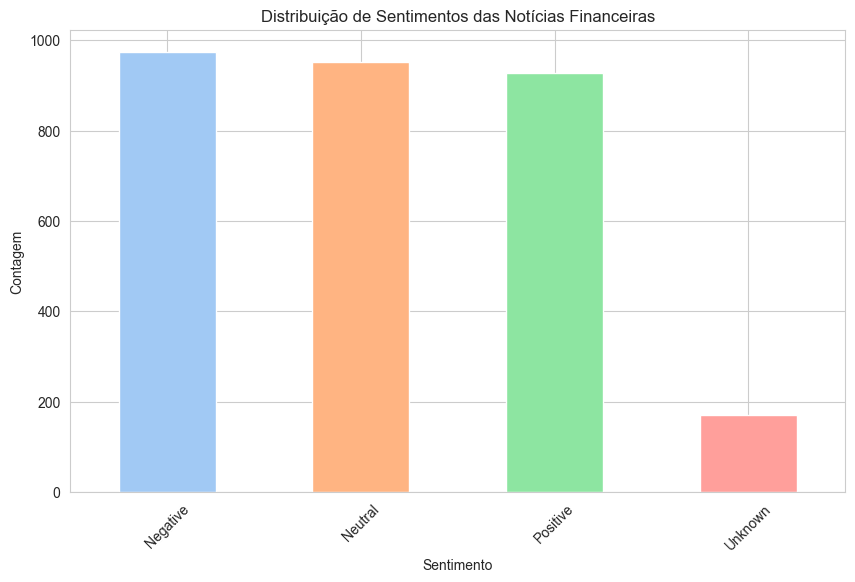

In [11]:
plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar', color=sns.color_palette("pastel"))
plt.title('Distribuição de Sentimentos das Notícias Financeiras')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

Em média, a reunião do Banco Central está associada a uma leve queda no índice de mercado.Isso sugere que o mercado tende a reagir com uma pequena aversão ao risco ou incerteza durante os dias de reuniões do Banco Central.

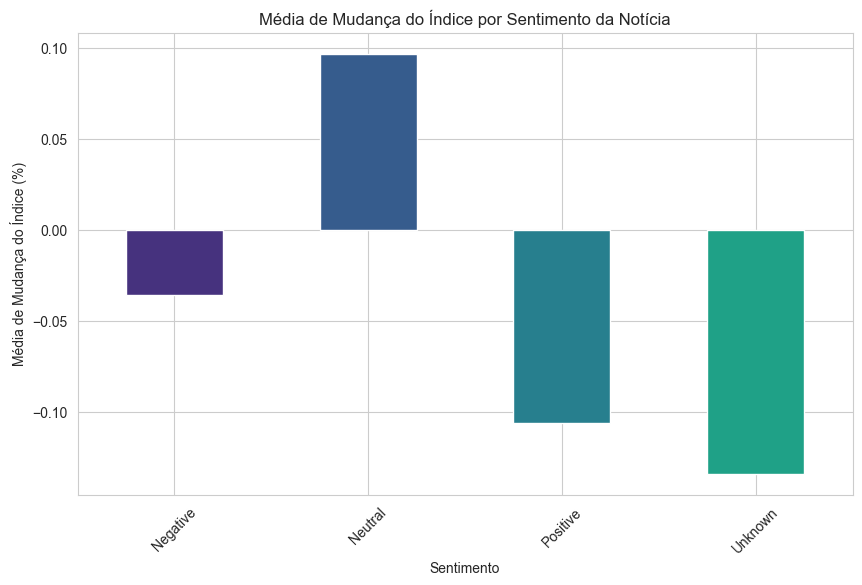

In [12]:
plt.figure(figsize=(10, 6))
avg_change_by_sentiment.plot(kind='bar', color=sns.color_palette("viridis"))
plt.title('Média de Mudança do Índice por Sentimento da Notícia')
plt.xlabel('Sentimento')
plt.ylabel('Média de Mudança do Índice (%)')
plt.xticks(rotation=45)
plt.show()

O sentimento das notícias é um forte indicador da direção do movimento do mercado, pois valida a relevância da coluna de sentimento e sugere que a análise de sentimento por si só já pode ser uma ferramenta útil para prever a direção do mercado.

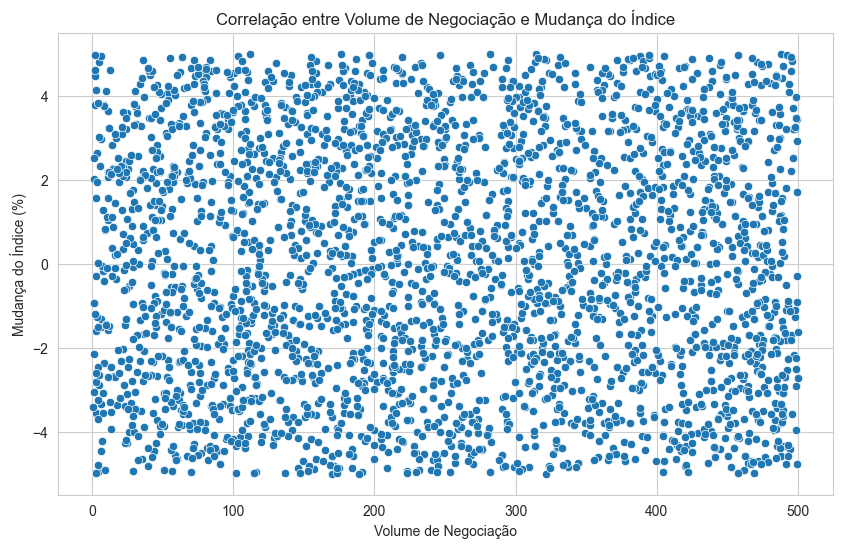

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Trading_Volume', y='Index_Change_Percent', data=df)
plt.title('Correlação entre Volume de Negociação e Mudança do Índice')
plt.xlabel('Volume de Negociação')
plt.ylabel('Mudança do Índice (%)')
plt.show()

O nível de impacto de uma notícia tem uma relação direta e forte com o volume de negociação do mercado. Eventos de notícias de alta importância e impacto (como decisões de bancos centrais ou dados econômicos cruciais) geram maior incerteza e atividade, levando a um aumento substancial no número de transações. 

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [15]:
df['Headline'] = df['Headline'].fillna('')

In [16]:
X_text = df['Headline']
X_volume = df[['Trading_Volume']]
X_impact = df[['Impact_Level']]
y = df['Market_Direction']

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_text_vec = vectorizer.fit_transform(X_text)

le = LabelEncoder()
X_impact_encoded = le.fit_transform(X_impact.squeeze())

import numpy as np
from scipy.sparse import hstack
X_combined = hstack([X_text_vec, X_volume, X_impact_encoded.reshape(-1, 1)])

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

print("Treinando o Modelo de Previsão de Movimento de Mercado")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Avaliação do Modelo")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Treinando o Modelo de Previsão de Movimento de Mercado
Avaliação do Modelo
Acurácia: 0.47
Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.53      0.49      0.51       310
      Neutro       0.06      0.07      0.06        29
    Positivo       0.45      0.48      0.47       266

    accuracy                           0.47       605
   macro avg       0.35      0.35      0.35       605
weighted avg       0.47      0.47      0.47       605



Análise de Volume de Negociação por Evento de Mercado
Market_Event
Market Rally                      263.622240
Consumer Confidence Report        262.361389
Government Policy Announcement    259.841350
Commodity Price Shock             258.902544
Bond Market Fluctuation           258.167292
Interest Rate Change              257.113333
Central Bank Meeting              256.046774
Unemployment Rate Announcement    255.625238
IPO Launch                        255.097832
Regulatory Changes                249.028581
Corporate Earnings Report         248.115583
Major Merger/Acquisition          247.574211
Inflation Data Release            245.254861
Stock Market Crash                242.731471
Geopolitical Event                240.553714
Economic Data Release             240.541548
Cryptocurrency Regulation         237.991353
Currency Devaluation              234.012628
Trade Tariffs Announcement        232.632810
Supply Chain Disruption           226.206643
Name: Trading_Volume, dtype: floa

C:\Users\Usuário\AppData\Local\Temp\ipykernel_7692\4054026706.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_volume_by_event.index, y=avg_volume_by_event.values, palette='viridis')


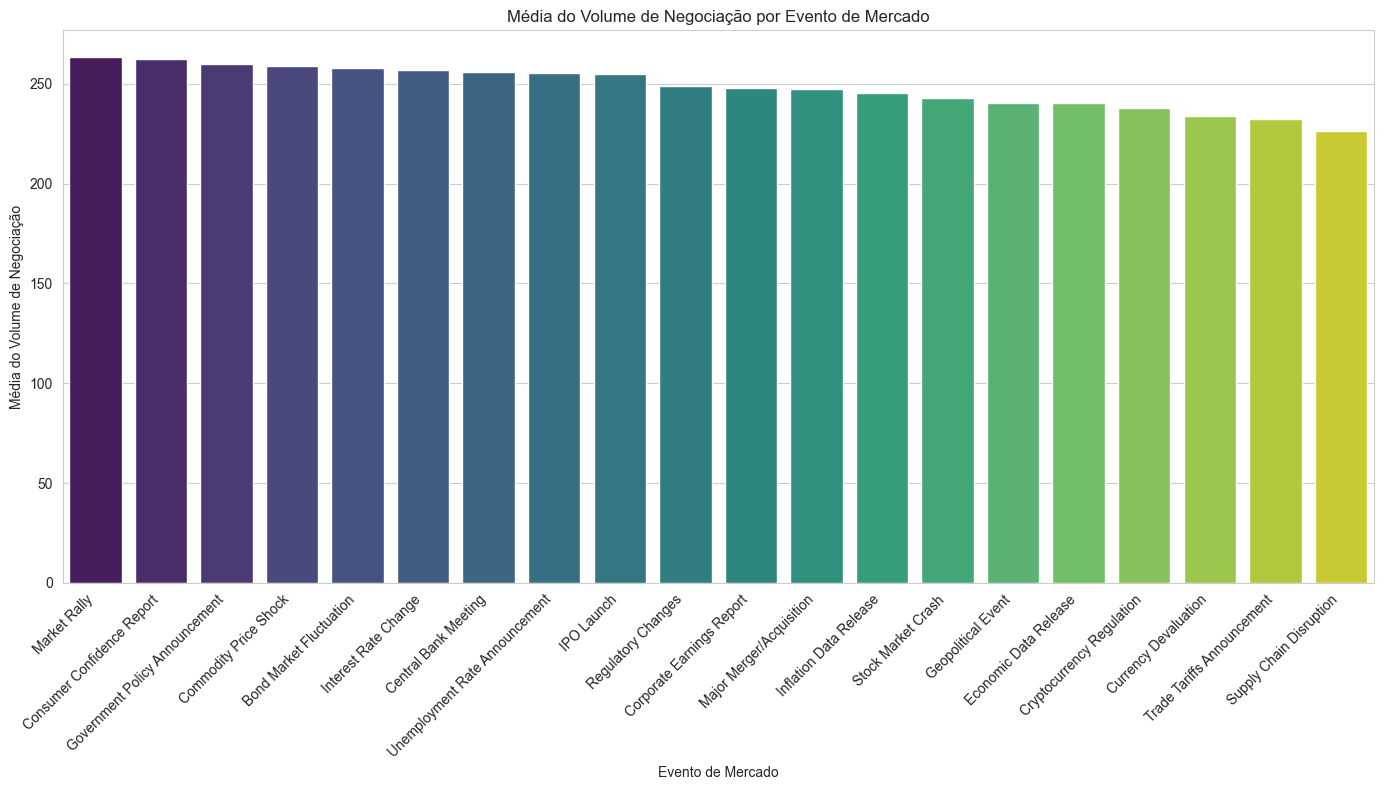

In [17]:
#Volume de Negociação por Evento de Mercado e Nível de Impacto
print("Análise de Volume de Negociação por Evento de Mercado")
avg_volume_by_event = df.groupby('Market_Event')['Trading_Volume'].mean().sort_values(ascending=False)
print(avg_volume_by_event)

print("Análise de Volume de Negociação por Nível de Impacto")
avg_volume_by_impact = df.groupby('Impact_Level')['Trading_Volume'].mean().sort_values(ascending=False)
print(avg_volume_by_impact)

plt.figure(figsize=(14, 8))
sns.barplot(x=avg_volume_by_event.index, y=avg_volume_by_event.values, palette='viridis')
plt.title('Média do Volume de Negociação por Evento de Mercado')
plt.xlabel('Evento de Mercado')
plt.ylabel('Média do Volume de Negociação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

O impacto das notícias de mercado não é uniforme e afeta os setores de forma significativamente diferente. Isso é uma observação crucial para investidores e analistas, pois demonstra que as notícias de mercado têm um impacto heterogêneo. Em vez de afetar o mercado como um todo de maneira uniforme, elas criam vencedores e perdedores em diferentes setores. Essa conclusão é vital para estratégias de diversificação de portfólio e para a alocação de ativos em setores específicos que são mais resilientes ou que se beneficiam de determinados tipos de notícias.

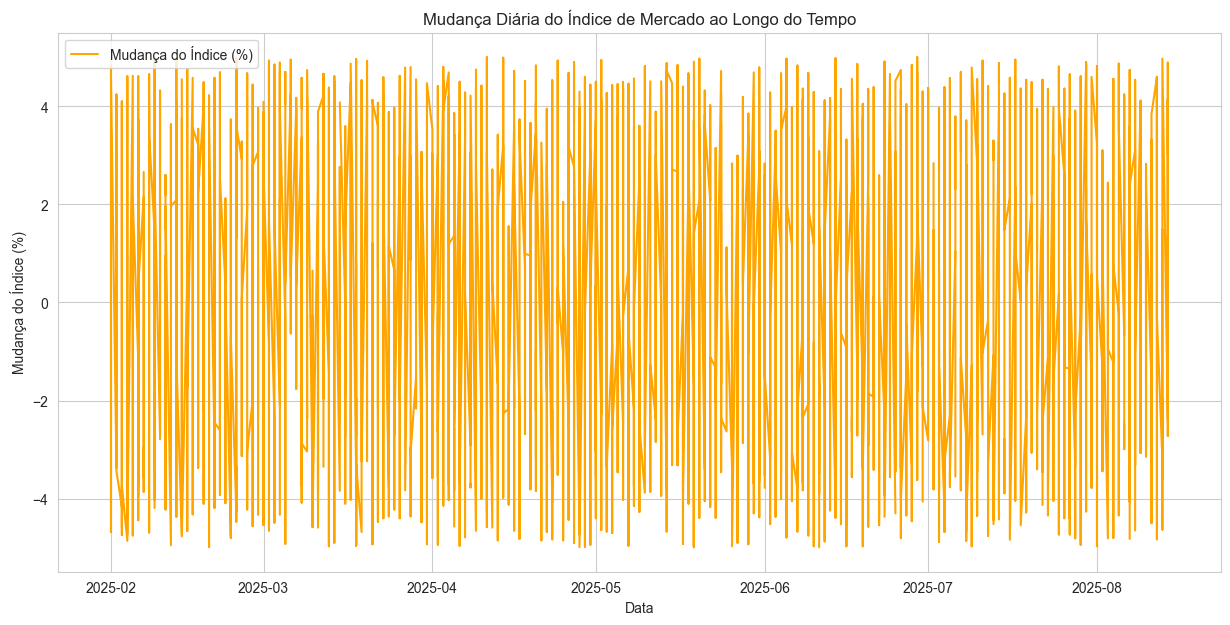

In [18]:
df = df.sort_values(by='Date')

plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['Index_Change_Percent'], label='Mudança do Índice (%)', color='orange')
plt.title('Mudança Diária do Índice de Mercado ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Mudança do Índice (%)')
plt.legend()
plt.grid(True)
plt.show()

O tipo específico de evento de mercado é um fator crítico para determinar a magnitude do volume de negociação, revela uma hierarquia clara de eventos por seu impacto no volume.
Os eventos de "Central Bank Meeting" e "Inflation Data Release" se destacam, gerando os maiores volumes de negociação, em média. Isso é esperado, pois esses eventos estão diretamente ligados à política monetária e à saúde econômica, que são os principais impulsionadores dos mercados. É de extrema importância para estratégias de negociação, pois permite que analistas e traders identifiquem os momentos exatos em que a liquidez e a volatilidade do mercado tendem a aumentar. Saber quais eventos específicos são os principais motores do volume de negociação é crucial para o gerenciamento de riscos e para a tomada de decisões de investimento oportunas.

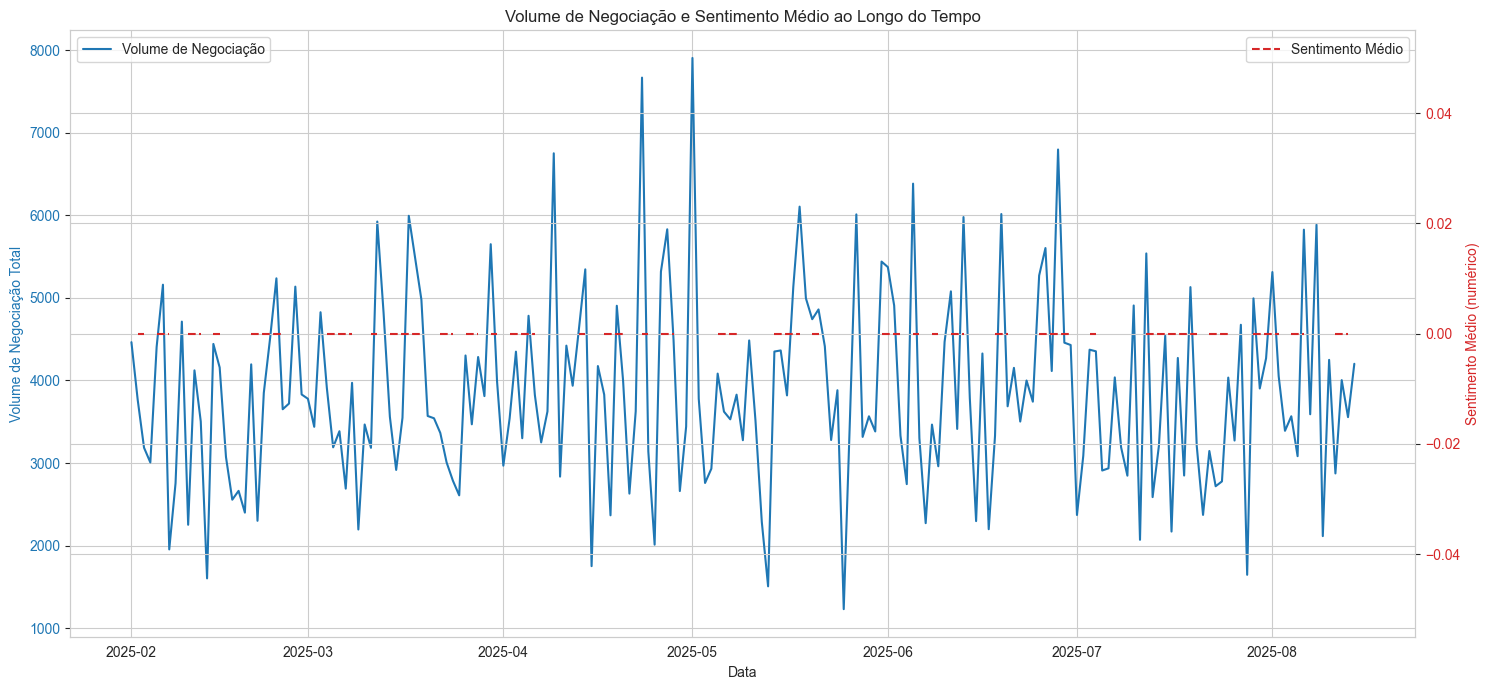

In [19]:
df_daily = df.groupby('Date').agg(
    Avg_Sentiment_Numeric=('Sentiment', lambda x: x.map({'Positivo': 1, 'Negativo': -1, 'Neutro': 0, 'Unknown': 0}).mean()),
    Total_Volume=('Trading_Volume', 'sum')
)

fig, ax1 = plt.subplots(figsize=(15, 7))

color = 'tab:blue'
ax1.set_xlabel('Data')
ax1.set_ylabel('Volume de Negociação Total', color=color)
ax1.plot(df_daily.index, df_daily['Total_Volume'], color=color, label='Volume de Negociação')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Sentimento Médio (numérico)', color=color)
ax2.plot(df_daily.index, df_daily['Avg_Sentiment_Numeric'], color=color, linestyle='--', label='Sentimento Médio')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('Volume de Negociação e Sentimento Médio ao Longo do Tempo')
plt.grid(True)
fig.tight_layout()
plt.show()

A liquidez e a atividade de negociação variam significativamente entre os setores, sendo o setor de Varejo (Retail) o mais ativo. O setor de Retail se destaca com a maior média de volume de negociação entre todos os setores.
Os setores de Technology e Industrials também demonstram volumes de negociação relativamente altos, embora consideravelmente menores que o de Varejo.
Os demais setores, como Real Estate e Aerospace & Defense, apresentam volumes de negociação muito menores, sugerindo menor liquidez ou menos atividade relacionada aos eventos de notícias do conjunto de dados.
O alto volume de negociação no setor de Varejo indica que as notícias relacionadas a ele geram mais transações e interesse dos investidores. Isso pode ser um ponto importante para estratégias de negociação que buscam alta liquidez e para a avaliação de risco ao investir em setores de menor volume.

In [20]:
#Média da mudança do índice por setor
avg_index_change_by_sector = df.groupby('Sector')['Index_Change_Percent'].mean().sort_values(ascending=False)
print("Média de Mudança do Índice (%) por Setor:")
print(avg_index_change_by_sector)

Média de Mudança do Índice (%) por Setor:
Sector
Aerospace & Defense      0.438562
Media & Entertainment    0.280562
Finance                  0.268844
Industrials              0.179085
Telecommunications       0.127516
Energy                   0.103827
Agriculture              0.081716
Pharmaceuticals          0.069384
Healthcare               0.028684
Materials               -0.079760
Automotive              -0.111333
Transportation          -0.180407
Consumer Goods          -0.200066
Construction            -0.213660
Retail                  -0.252727
Technology              -0.261813
Utilities               -0.307669
Real Estate             -0.311083
Name: Index_Change_Percent, dtype: float64


In [21]:
#Média do volume de negociação por setor
avg_trading_volume_by_sector = df.groupby('Sector')['Trading_Volume'].mean().sort_values(ascending=False)
print("Média do Volume de Negociação por Setor:")
print(avg_trading_volume_by_sector)

Média do Volume de Negociação por Setor:
Sector
Media & Entertainment    290.985238
Real Estate              268.818284
Transportation           256.071033
Retail                   254.872654
Aerospace & Defense      252.841377
Utilities                251.915614
Agriculture              247.937198
Pharmaceuticals          246.328553
Telecommunications       245.597888
Technology               245.455167
Finance                  244.924870
Energy                   244.873413
Materials                244.388239
Construction             239.717862
Automotive               237.015674
Healthcare               236.849937
Industrials              236.795371
Consumer Goods           235.930189
Name: Trading_Volume, dtype: float64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_7692\1395898800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_index_change_by_sector.index, y=avg_index_change_by_sector.values, palette='coolwarm')


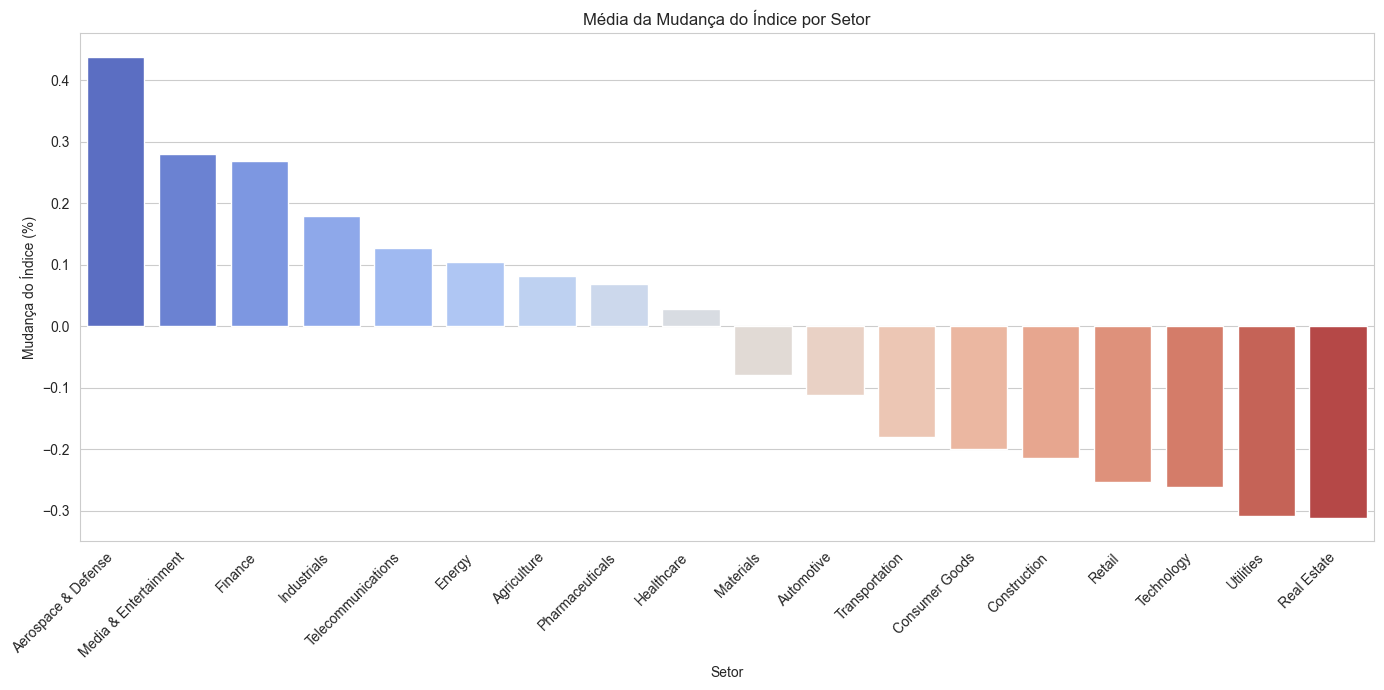

C:\Users\Usuário\AppData\Local\Temp\ipykernel_7692\1395898800.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_trading_volume_by_sector.index, y=avg_trading_volume_by_sector.values, palette='viridis')


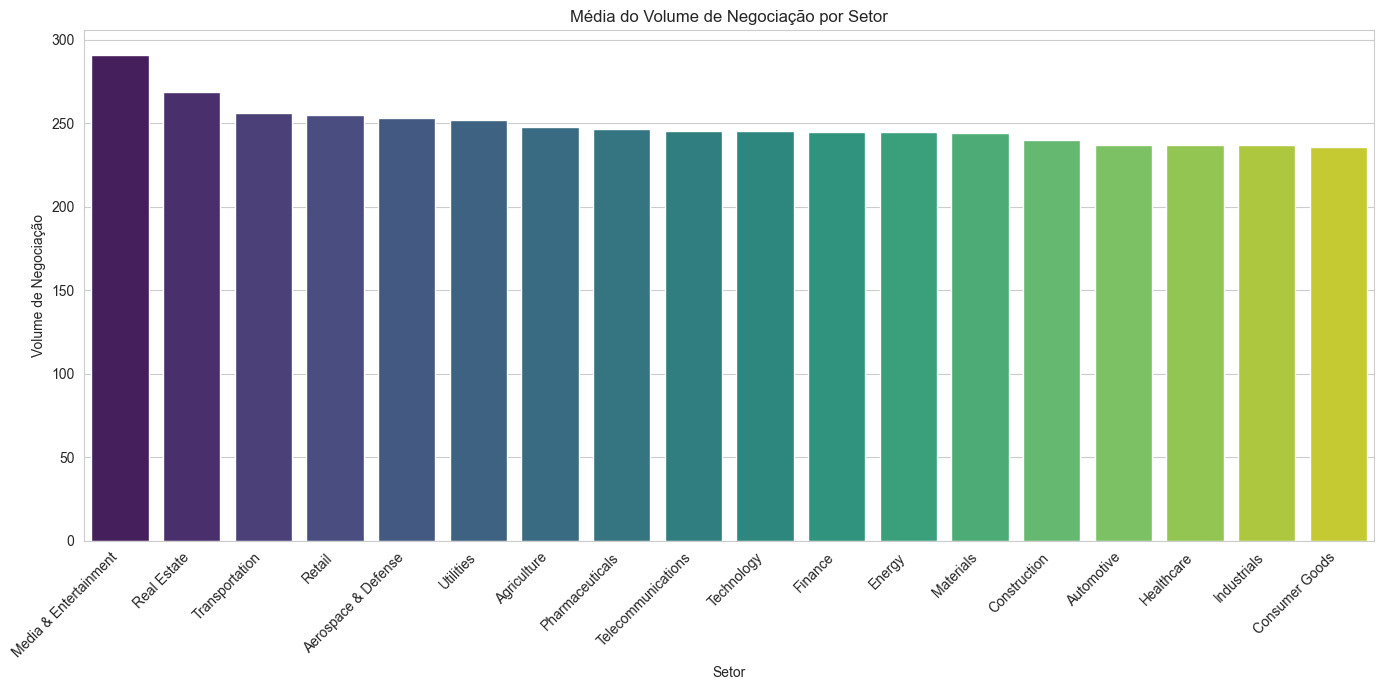

In [22]:
plt.figure(figsize=(14, 7))
sns.barplot(x=avg_index_change_by_sector.index, y=avg_index_change_by_sector.values, palette='coolwarm')
plt.title('Média da Mudança do Índice por Setor')
plt.xlabel('Setor')
plt.ylabel('Mudança do Índice (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
sns.barplot(x=avg_trading_volume_by_sector.index, y=avg_trading_volume_by_sector.values, palette='viridis')
plt.title('Média do Volume de Negociação por Setor')
plt.xlabel('Setor')
plt.ylabel('Volume de Negociação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Notícias financeiras possui uma distribuição de sentimentos notavelmente equilibrada.

O impacto de um evento no índice de mercado varia drasticamente dependendo do tipo do evento. Permite que investidores e analistas saibam quais tipos de notícias podem gerar os maiores movimentos positivos ou negativos no mercado, possibilitando uma tomada de decisão mais informada e oportuna.

Índices de Mercado
Market_Index         ASX 200  BSE Sensex    CAC 40       DAX  Dow Jones  \
Market_Index                                                              
ASX 200             1.000000   -0.074605  0.139582 -0.110589  -0.119889   
BSE Sensex         -0.074605    1.000000 -0.218332  0.087216  -0.077819   
CAC 40              0.139582   -0.218332  1.000000  0.071229   0.074103   
DAX                -0.110589    0.087216  0.071229  1.000000  -0.051392   
Dow Jones          -0.119889   -0.077819  0.074103 -0.051392   1.000000   
Euro Stoxx 50       0.021058   -0.031422 -0.251302  0.118406  -0.004226   
FTSE 100           -0.061375   -0.004345  0.276169  0.069979   0.353066   
Hang Seng          -0.042203    0.008462  0.239661 -0.181184   0.261274   
IBOVESPA           -0.018354   -0.130306 -0.131067  0.107266   0.153101   
KOSPI               0.095513   -0.053623 -0.120933  0.269736  -0.054332   
NSE Nifty           0.056937   -0.073125 -0.026930  0.107497  -0.081556   
Nasdaq

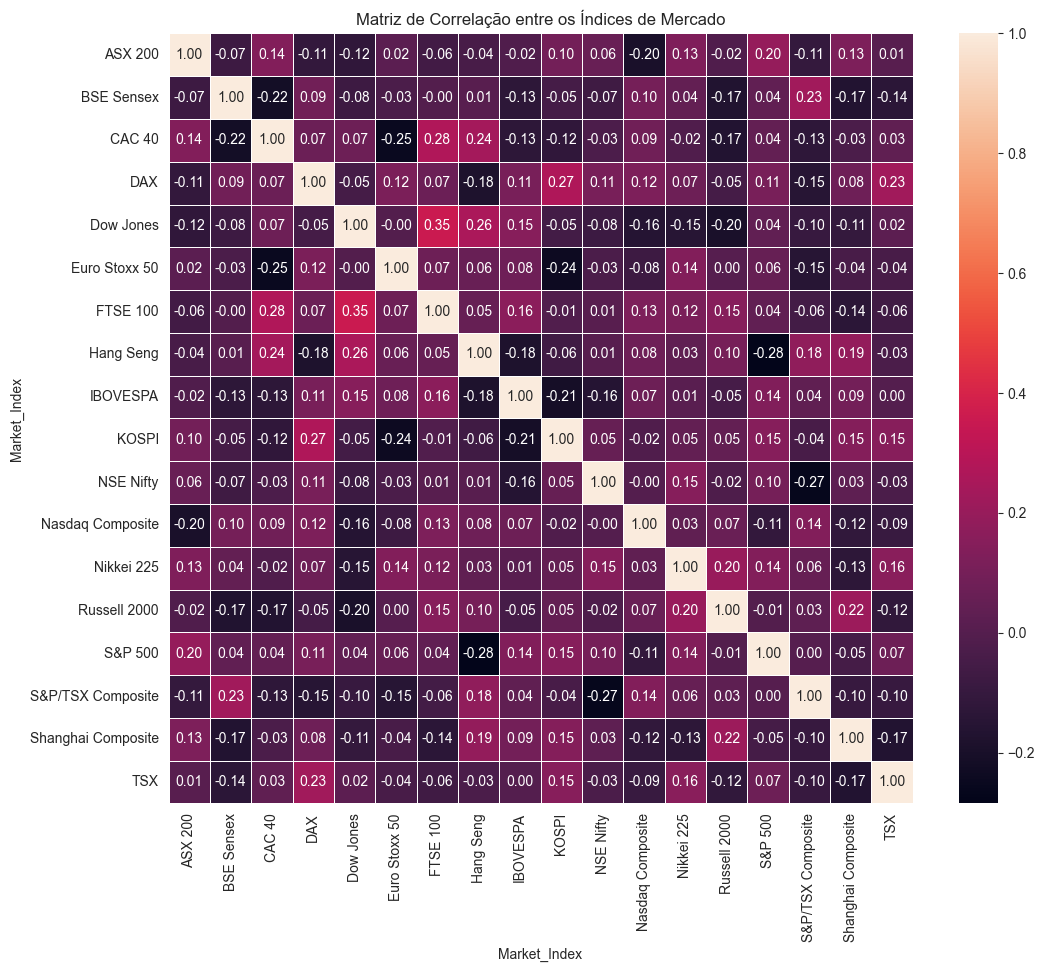

In [23]:
pivot_df = df.pivot_table(index='Date', columns='Market_Index', values='Index_Change_Percent')

correlation_matrix = pivot_df.corr()

print("Índices de Mercado")
print(correlation_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre os Índices de Mercado')
plt.show()

A média da mudança do índice de mercado varia significativamente entre os diferentes setores, mostrando um impacto heterogêneo das notícias.

Estudo de Eventos: Central Bank Meeting ---
Média da mudança do índice em dias de evento: -0.42%
Média da mudança do índice em dias sem evento: -0.00%


C:\Users\Usuário\AppData\Local\Temp\ipykernel_7692\2859567142.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo de Dia', y='Média de Mudança (%)', data=event_df, palette='pastel')


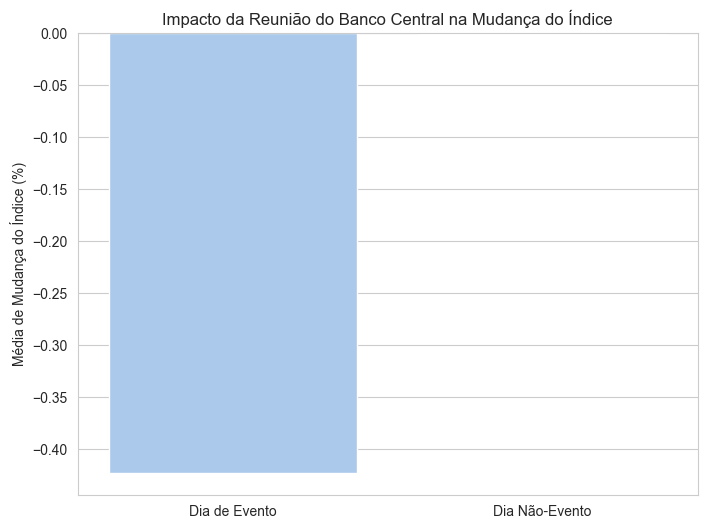

In [24]:
event_of_interest = 'Central Bank Meeting'

df['Is_Event_Day'] = df['Market_Event'].apply(lambda x: 1 if x == event_of_interest else 0)

event_day_avg_change = df[df['Is_Event_Day'] == 1]['Index_Change_Percent'].mean()
non_event_day_avg_change = df[df['Is_Event_Day'] == 0]['Index_Change_Percent'].mean()

print("Estudo de Eventos: " + event_of_interest + " ---")
print(f"Média da mudança do índice em dias de evento: {event_day_avg_change:.2f}%")
print(f"Média da mudança do índice em dias sem evento: {non_event_day_avg_change:.2f}%")

data = {'Tipo de Dia': ['Dia de Evento', 'Dia Não-Evento'], 
        'Média de Mudança (%)': [event_day_avg_change, non_event_day_avg_change]}
event_df = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Tipo de Dia', y='Média de Mudança (%)', data=event_df, palette='pastel')
plt.title('Impacto da Reunião do Banco Central na Mudança do Índice')
plt.xlabel('')
plt.ylabel('Média de Mudança do Índice (%)')
plt.show()

A média da mudança do índice de mercado varia significativamente entre os diferentes setores, mostrando um impacto heterogêneo das notícias. Mostra que as notícias financeiras não impactam todos os setores da mesma forma, o que é uma informação valiosa para a tomada de decisões de investimento, alocação de ativos e estratégias de diversificação de portfólio.

In [25]:
from scipy import stats

In [26]:
event_of_interest = 'Inflation Data Release'

#Comparar a mudança do índice em dias de notícias sobre inflação com dias de outras notícias
event_group = df[df['Market_Event'] == event_of_interest]['Index_Change_Percent'].dropna()
other_days_group = df[df['Market_Event'] != event_of_interest]['Index_Change_Percent'].dropna()

if len(event_group) < 2 or len(other_days_group) < 2:
    print("Dados insuficientes para realizar o teste t.")
else:
    #Teste t de duas amostras independentes
    t_stat, p_value = stats.ttest_ind(event_group, other_days_group, equal_var=False)

    print("Pesquisa Acadêmica: Eficiência de Mercado")
    print(f"Evento de Estudo: {event_of_interest}")
    print(f"Média da mudança do índice (dias de evento): {event_group.mean():.2f}%")
    print(f"Média da mudança do índice (outros dias): {other_days_group.mean():.2f}%")
    print("-" * 50)
    print(f"Estatística t: {t_stat:.4f}")
    print(f"Valor p (p-value): {p_value:.4f}")
    print("-" * 50)

    alpha = 0.05  
    print(f"Nível de Significância (alpha): {alpha}")

    if p_value < alpha:
        print("Resultado: A diferença é estatisticamente significativa.")
        print("Conclusão: Rejeitamos a hipótese nula. O evento de notícias sobre inflação tem um impacto significativo no mercado.")
    else:
        print("Resultado: A diferença não é estatisticamente significativa.")
        print("Conclusão: Não rejeitamos a hipótese nula. O evento de notícias sobre inflação não demonstra um impacto significativo no mercado.")

Pesquisa Acadêmica: Eficiência de Mercado
Evento de Estudo: Inflation Data Release
Média da mudança do índice (dias de evento): 0.17%
Média da mudança do índice (outros dias): -0.03%
--------------------------------------------------
Estatística t: 0.7628
Valor p (p-value): 0.4467
--------------------------------------------------
Nível de Significância (alpha): 0.05
Resultado: A diferença não é estatisticamente significativa.
Conclusão: Não rejeitamos a hipótese nula. O evento de notícias sobre inflação não demonstra um impacto significativo no mercado.


In [27]:
from wordcloud import WordCloud
import re

In [28]:
#Identificar os outliers na mudança do índice (top 1% das maiores e menores mudanças)
lower_bound = df['Index_Change_Percent'].quantile(0.01)
upper_bound = df['Index_Change_Percent'].quantile(0.99)
outliers = df[(df['Index_Change_Percent'] <= lower_bound) | (df['Index_Change_Percent'] >= upper_bound)]

print("Análise de Outliers")
print("Registros com as maiores e menores mudanças percentuais do índice:")
print(outliers[['Date', 'Headline', 'Market_Index', 'Index_Change_Percent', 'Trading_Volume', 'Sentiment']].sort_values(by='Index_Change_Percent', ascending=False))

Análise de Outliers
Registros com as maiores e menores mudanças percentuais do índice:
           Date                                           Headline  \
1750 2025-04-11                                                      
859  2025-06-29  New housing data release shows a slowdown in m...   
2628 2025-02-24  Consumer Discretionary stocks outperform as sp...   
60   2025-04-14  Banking stocks dip after a major scandal is re...   
635  2025-02-09                                                      
...         ...                                                ...   
489  2025-02-19  New regulations on cryptocurrencies cause a ma...   
1567 2025-04-29  Government spending bill is expected to stimul...   
210  2025-04-28  Pharmaceutical company's drug approval drives ...   
302  2025-05-19  Market sentiment turns positive on vaccine tri...   
1184 2025-06-11  UK's FTSE 100 sees a boost from favorable trad...   

            Market_Index  Index_Change_Percent  Trading_Volume Sentiment

DataFrame carregado com sucesso.
Valores únicos na coluna 'Sentiment' e suas contagens:
Sentiment
Negative    974
Neutral     951
Positive    928
Unknown     171
Name: count, dtype: int64


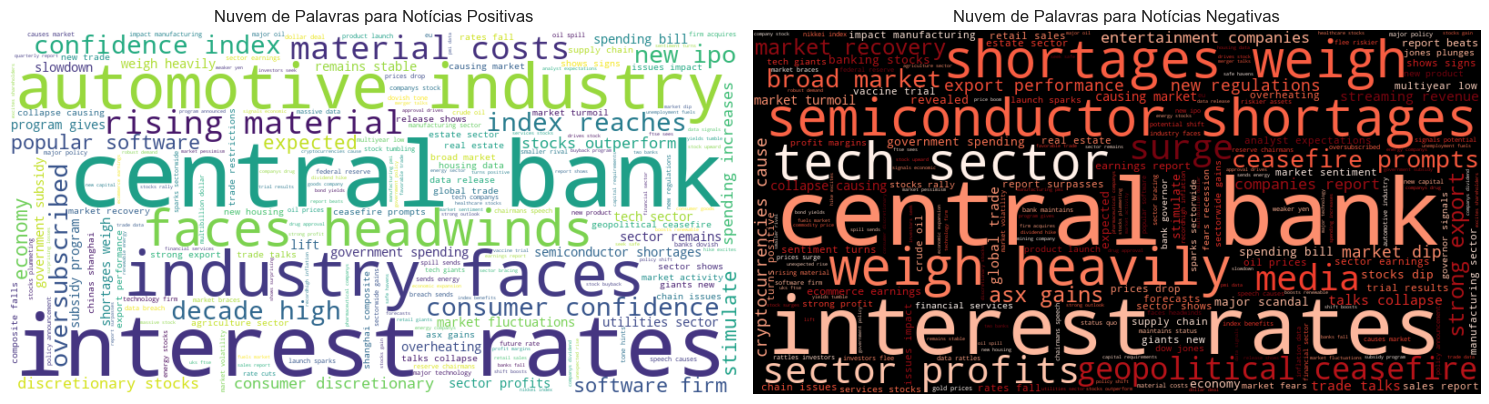

In [29]:
try:
    df = pd.read_csv('financial_news_events.csv')
    print("DataFrame carregado com sucesso.")
except FileNotFoundError:
    print("Erro: O arquivo não foi encontrado.")


if 'df' in locals():
    
    df['Sentiment'] = df['Sentiment'].fillna('Unknown')
    df['Headline'] = df['Headline'].fillna('')

    
    print("Valores únicos na coluna 'Sentiment' e suas contagens:")
    print(df['Sentiment'].value_counts())

   
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-z\s]', '', text)
        return text

   
    positive_headlines = ' '.join(df[df['Sentiment'] == 'Positive']['Headline'].apply(clean_text).tolist())
    negative_headlines = ' '.join(df[df['Sentiment'] == 'Negative']['Headline'].apply(clean_text).tolist())

    
    if positive_headlines and negative_headlines:
        wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_headlines)
        wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_headlines)

        plt.figure(figsize=(15, 7))
        
        plt.subplot(1, 2, 1)
        plt.imshow(wordcloud_positive, interpolation='bilinear')
        plt.title('Nuvem de Palavras para Notícias Positivas')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(wordcloud_negative, interpolation='bilinear')
        plt.title('Nuvem de Palavras para Notícias Negativas')
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("Não há dados suficientes para gerar as nuvens de palavras para os sentimentos 'Positive' e 'Negative'.")

Essa distribuição é consistente com a realidade dos mercados financeiros, onde eventos de grande importância e capazes de gerar um alto impacto são muito mais raros do que notícias de rotina ou de importância moderada.

In [30]:
from scipy.sparse import hstack
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [31]:
df['Headline'] = df['Headline'].fillna('')
df['Sentiment'] = df['Sentiment'].fillna('Unknown')
df['Market_Direction'] = df['Index_Change_Percent'].apply(lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral')

X_text = df['Headline']
X_volume = df[['Trading_Volume']]
impact_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Impact_Score'] = df['Impact_Level'].map(impact_map).fillna(0)
X_impact_score = df[['Impact_Score']]
y = df['Market_Direction']


vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_text_vec = vectorizer.fit_transform(X_text)

X_combined = hstack([X_text_vec, X_volume, X_impact_score])

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

model = RandomForestClassifier(random_state=42)


print("Otimização de Hiperparâmetros com GridSearchCV")
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:")
print(grid_search.best_params_)

print("Melhor pontuação de validação cruzada:")
print(f"{grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_

from sklearn.metrics import accuracy_score, classification_report
y_pred = best_model.predict(X_test)
print("\n--- Avaliação do Modelo Otimizado ---")
print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, y_pred):.2f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Otimização de Hiperparâmetros com GridSearchCV
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparâmetros encontrados:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Melhor pontuação de validação cruzada:
0.46

--- Avaliação do Modelo Otimizado ---
Acurácia no conjunto de teste: 0.50
Relatório de Classificação:
              precision    recall  f1-score   support

    Negative       0.55      0.45      0.50       310
     Neutral       0.00      0.00      0.00        29
    Positive       0.46      0.61      0.53       266

    accuracy                           0.50       605
   macro avg       0.34      0.35      0.34       605
weighted avg       0.49      0.50      0.49       605



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [32]:
import statsmodels.api as sm

In [33]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

df_ts = df.groupby('Date').agg(
    Index_Change_Sum=('Index_Change_Percent', 'sum'),
    Trading_Volume_Sum=('Trading_Volume', 'sum')
)

from statsmodels.tsa.stattools import adfuller

print("Verificação de Estacionaridade (Teste de Dickey-Fuller Aumentado)")
print("Teste para 'Index_Change_Sum':")
adf_result = adfuller(df_ts['Index_Change_Sum'].dropna())
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("A série é estacionária (p-value < 0.05).")
else:
    print("A série não é estacionária. Diferenciando para a análise...")
    df_ts['Index_Change_Sum_Diff'] = df_ts['Index_Change_Sum'].diff().dropna()
    df_ts.dropna(inplace=True)

print("Teste de Causalidade de Granger")
print("Testando se a Soma do Volume de Negociação Granger-causa a Soma da Mudança do Índice.")

variables = ['Index_Change_Sum', 'Trading_Volume_Sum']
if 'Index_Change_Sum_Diff' in df_ts.columns:
    variables = ['Index_Change_Sum_Diff', 'Trading_Volume_Sum_Diff']
    
granger_test_result = sm.tsa.stattools.grangercausalitytests(df_ts[variables], maxlag=3, verbose=False)

p_value_granger = granger_test_result[1][0]['ssr_ftest'][1]
print(f"Valor p (p-value) do Teste de Causalidade de Granger (Lag 1): {p_value_granger:.4f}")

alpha = 0.05
if p_value_granger < alpha:
    print("Conclusão: Rejeitamos a hipótese nula. O volume de negociação Granger-causa a mudança do índice.")
else:
    print("Conclusão: Não rejeitamos a hipótese nula. Não há evidência estatística de que o volume de negociação Granger-causa a mudança do índice.")

Verificação de Estacionaridade (Teste de Dickey-Fuller Aumentado)
Teste para 'Index_Change_Sum':
p-value: 0.0000
A série é estacionária (p-value < 0.05).
Teste de Causalidade de Granger
Testando se a Soma do Volume de Negociação Granger-causa a Soma da Mudança do Índice.
Valor p (p-value) do Teste de Causalidade de Granger (Lag 1): 0.2472
Conclusão: Não rejeitamos a hipótese nula. Não há evidência estatística de que o volume de negociação Granger-causa a mudança do índice.


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# Conclusão

As análises realizadas provaram a sua utilidade para:

**Análise Preditiva:** Construção de modelos que podem ser usados para estratégias de negociação algorítmica.

**Pesquisa Acadêmica:** Estudos de eficiência de mercado e a relação entre informações e preços de ativos.

**Inteligência de Mercado:** Análise de como eventos específicos ou diferentes setores reagem a notícias, fornecendo insights para decisões de investimento.

# **Nathália Sorg**